# Chaining LLMs with `LangChain`

How can we extend the functionality of LLMs in ways other than fine-tuning?
1. Exploiting LLM memory
2. Chains
3. Tools
4. Agents

Some of these will be handled in this notebook and others in ensuing ones.

Generative AI (GAI) has accelerated with the advent of large language models (LLMs). Here is a nice introduction to LLMs that is not technical to get started: https://www.understandingai.org/p/large-language-models-explained-with.

`LangChain` is a library that wraps much of the functionality around using large language models (LLMs) into simple commands that make using LLMs very easy and efficient. The documentation is shown below, along with some useful links.

- Docs: https://python.langchain.com/docs/introduction/; API: https://python.langchain.com/api_reference/

- https://www.mikulskibartosz.name/ai-data-analyst-bot-for-slack-with-gpt-and-langchain/

James Briggs:
1. https://www.youtube.com/watch?v=nE2skSRWTTs&list=PLIUOU7oqGTLge073ctEsETY8XrDI-4Mb8
2. https://www.youtube.com/watch?v=RflBcK0oDH0

LangChain 101: https://www.youtube.com/results?search_query=langchain+101

PineCone's LangChain Manual: https://www.pinecone.io/learn/langchain/

The `LangChain` library helps with calling LLM APIs, prompt construction, chaining prompts, using search in real time as part of its `tools` and `agents` that handle specific types of tasks such as reasoning about how they construct the response.

Alternate libraries similar to LangChain:
- LlamaIndex: https://github.com/jerryjliu/llama_index
- AutoChain: https://github.com/Forethought-Technologies/AutoChain

Below, we install the library for LangChain and also from other providers such as OpenAI (to call gpt-3.5 and da-vinci-003 models). We also install Hugging Face's hub to enable their APIs, and Wolfram Alpha's library to use their APIs. The FAISS library from Meta helps with construction of and retrieval from vector databases that store embeddings from the text of documents used with the LLM. We will also use the [ChromaDB](https://www.trychroma.com) vector database for applications and learn how this is used.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # Add My Drive/<>

import os
os.chdir('drive/My Drive')
os.chdir('Books_Writings/NLPBook/')

Mounted at /content/drive


In [ ]:
%%capture
%pylab inline
import pandas as pd
import os
from IPython.display import Image

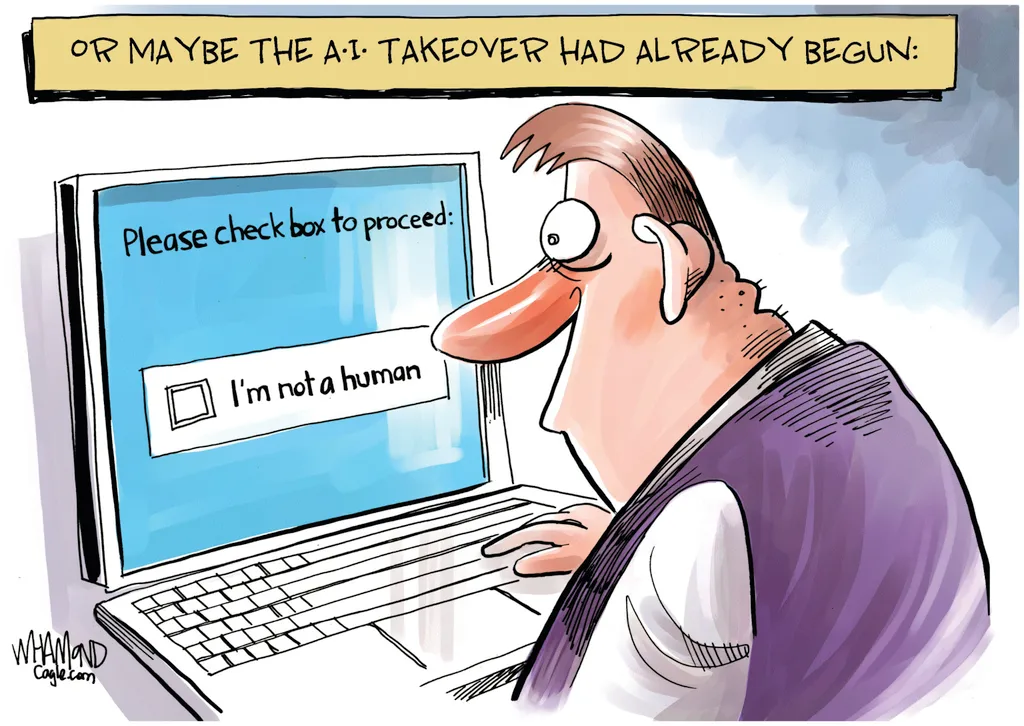

In [ ]:
Image('NLP_images/human.png', width=800)

## Compound AI Systems

https://bair.berkeley.edu/blog/2024/02/18/compound-ai-systems/

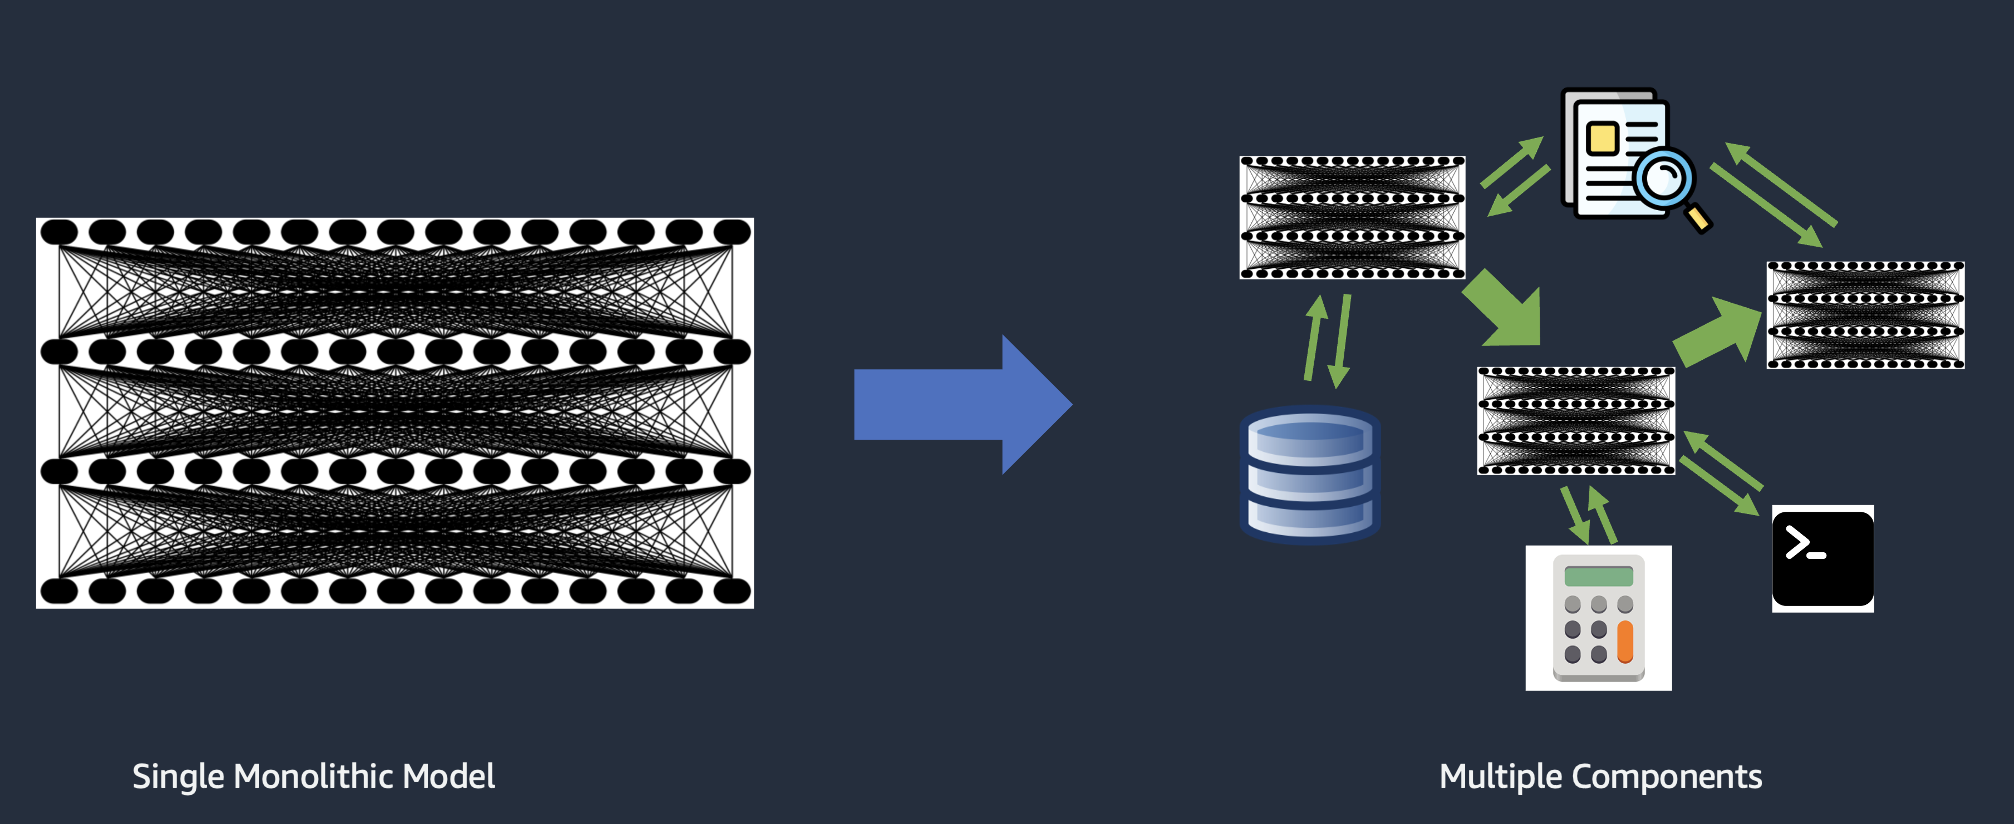

In [ ]:
Image('NLP_images/compound_ai.png', width=800)

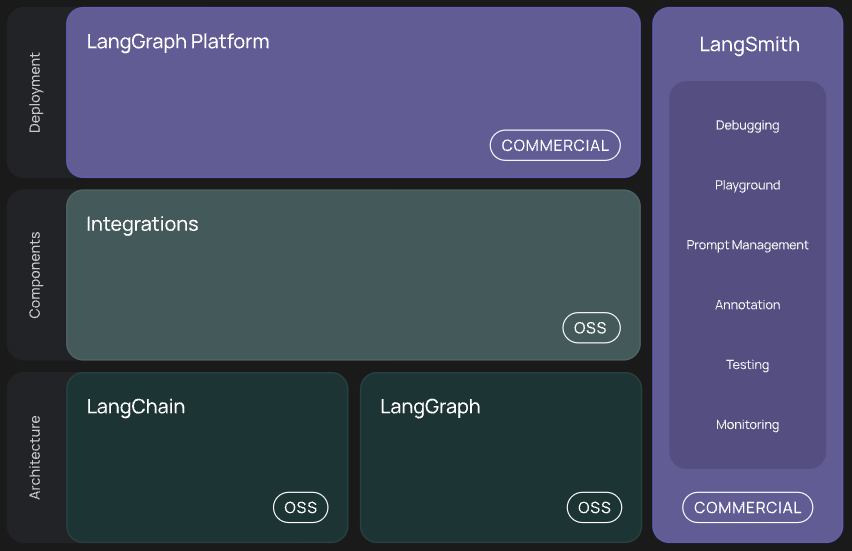

In [ ]:
Image('NLP_images/langchain_stack.png', width=800)

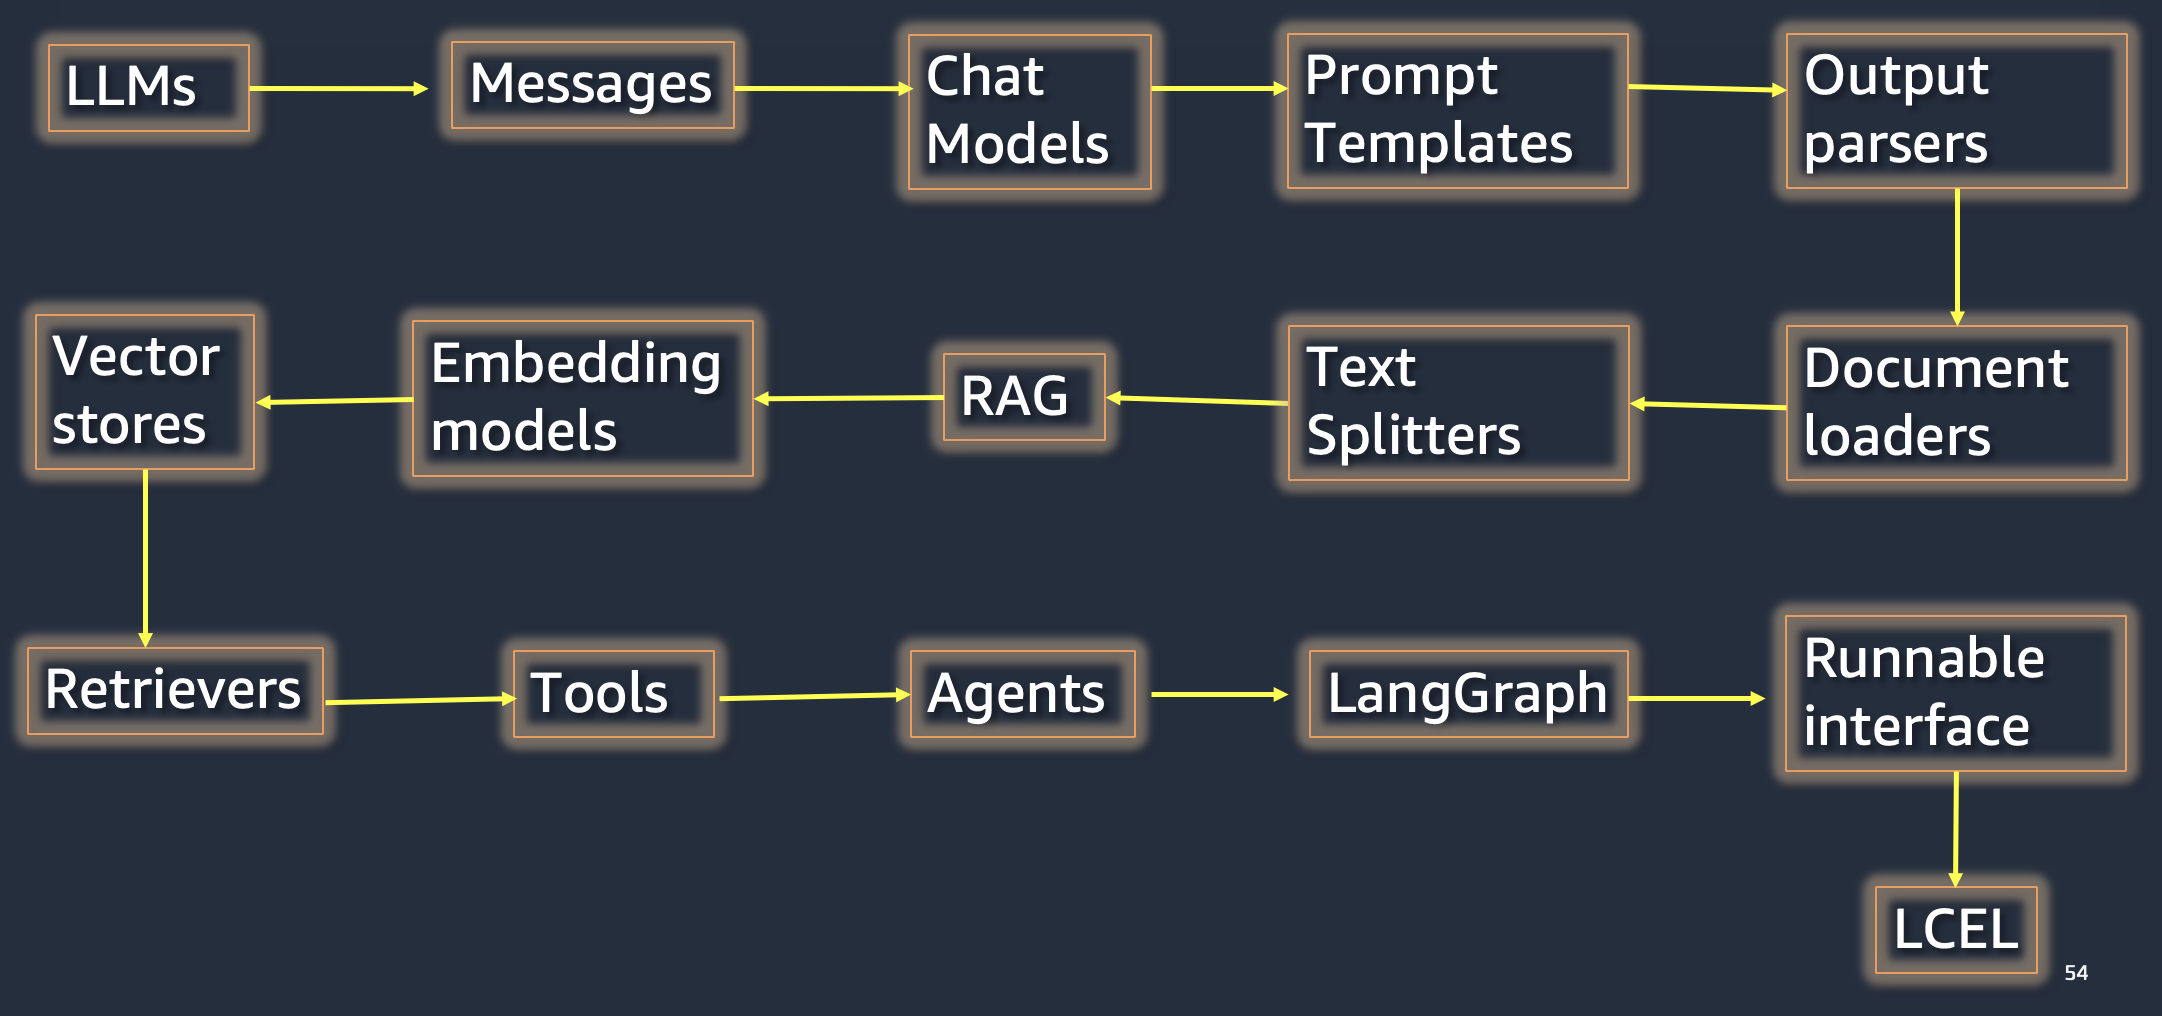

In [ ]:
Image('NLP_images/langchain_components.png', width=800)

## What does `LangChain` provide?

1. Standardized component interfaces: Unifies the APIs offered by models and related components, making it easy to switch providers.

2. Orchestration provides an efficient framework for combining multiple components and models to accomplish diverse tasks.

3. Obersvability and evaluation helps developers monitor their applications and provide insights into what is happening in them.

## Building things in finance

1. Personalized Financial Advisor: AI-powered chatbot providing tailored financial advice based on individual circumstances and goals.

2. Market Sentiment Analysis: System analyzing financial news and social media to gauge market sentiment and predict trends.

3. Automated Financial Report Generation: Tool that automatically creates detailed financial reports from raw data for easy comprehension.

4. Risk Assessment Tool: Application assessing financial instrument risks by analyzing historical data and market trends.

5. Fraud Detection System: AI-driven system analyzing transaction data to identify potentially fraudulent activities.

## Install all the packages for GAI

We use the `requirements_gai.txt` file for this. The packages are:

```
matplotlib
numpy
ipypublish
openai
langchain-openai
chromadb
langchain
langchain_community
tiktoken
unstructured
langchain_huggingface
huggingface_hub
wolframalpha
faiss-cpu
google-search-results
python-magic
nest_asyncio
```

In [ ]:
%%time
# Installs
!pip install --upgrade pip --quiet
!pip install -r requirements_gai.txt --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-exporter-otlp-proto-common==1.37.0, but y

In [ ]:
%pylab inline
import os
import textwrap
import openai
import wolframalpha
import faiss

def p80(text):
    print(textwrap.fill(text, 80))
    return None

Populating the interactive namespace from numpy and matplotlib


## Load in API Keys

Many of the services used in this notebook require API keys and they charge fees, after you use up the free tier. We store the keys in a separate notebook so as to not reveal them here. Then by running that notebook all the keys are added to the environment.

Set up your own notebook with the API keys and it should look as follows:

```
import os

OPENAI_KEY = '<Your API Key here>'
os.environ['OPENAI_API_KEY'] = OPENAI_KEY

HF_API_KEY = '<Your API Key here>'
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_API_KEY

SERPAPI_KEY = '<Your API Key here>'
os.environ['SERPAPI_API_KEY'] = SERPAPI_KEY

WOLFRAM_ALPHA_KEY = '<Your API Key here>'
os.environ['WOLFRAM_ALPHA_APPID'] = WOLFRAM_ALPHA_KEY

GOOGLE_KEY = '<Your API Key here>'

keys = ['OPENAI_KEY', 'HF_API_KEY', 'SERPAPI_KEY', 'WOLFRAM_ALPHA_KEY']
print("Keys available: ", keys)
```



In [ ]:
%run keys.ipynb

## Using LLMs: Hugging Face

See: https://huggingface.co/docs/transformers/model_doc/flan-t5

The code below shows how to use the FLAN-T5 model with `langchain`.

The `temperature` parameter (ranging from 0 to 1) determines how much variation there will be in the responses from the LLM. This is based on how the LLM chooses the next word in the sequence. If `temperature=0` then the LLM will always choose the most likely word. But if `temerature>0` then the next word is chosen from a collection of top probability words, where this collection becomes larger as this parameter increases. That's all there is to it. Hence, higher temperate means greater variety in the text generated. (I am not sure why this nomenclature was chosen for this parameter.)

https://api.python.langchain.com/en/latest/llms/langchain.llms.huggingface_hub.HuggingFaceHub.html#langchain.llms.huggingface_hub.HuggingFaceHub

Here is a nice blog that explains how to use Hugging Face and the code below is abstracted from it: https://huggingface.co/blog/langchain


In [ ]:
# From the link for FLAN-T5: https://huggingface.co/docs/transformers/model_doc/flan-t5

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")

inputs = tokenizer("A step by step recipe to make bolognese pasta:", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=50)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

['Pour a cup of bolognese into a large bowl and add the pasta to the bowl.']


## `LangChain` Messages

1. Messages are of different types shown below.

2. Contain role, content, and optional response metadata/tool calls.

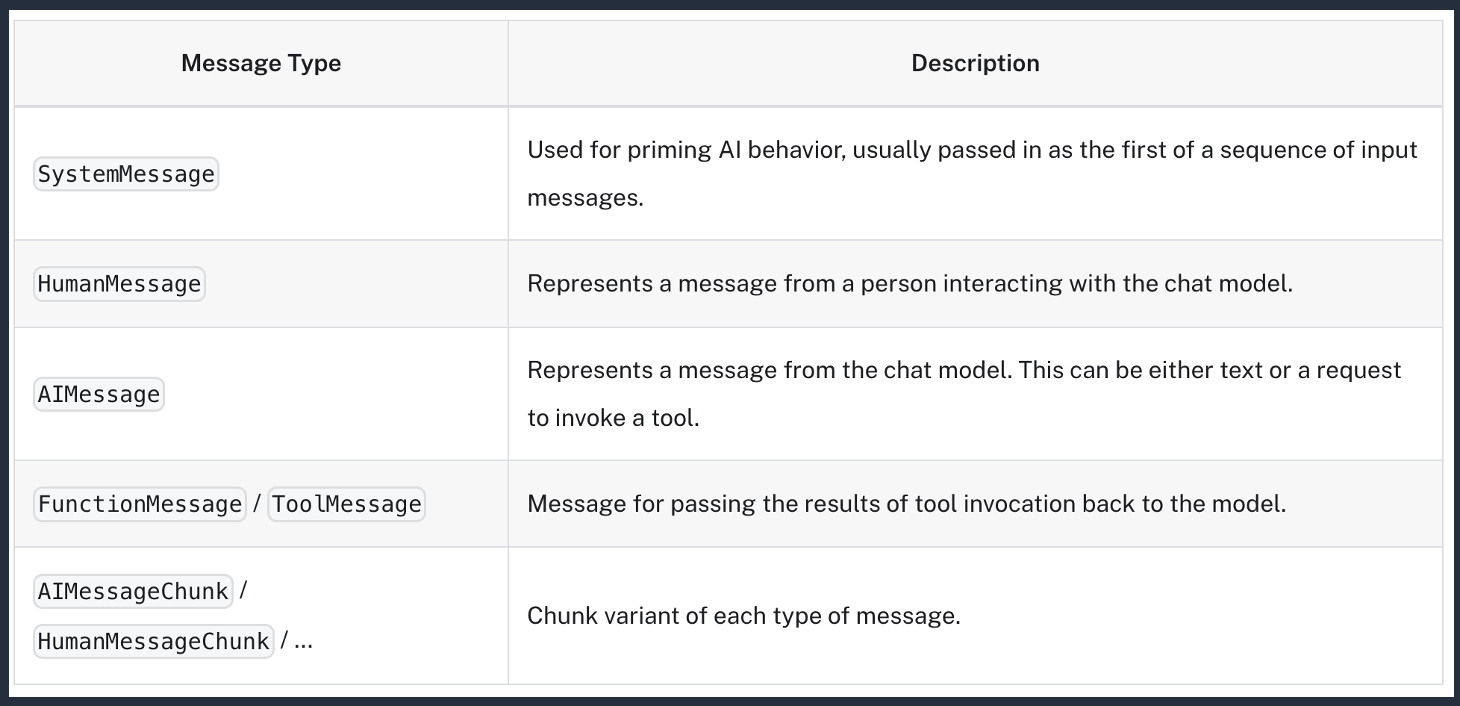

In [ ]:
Image('NLP_images/langchain_messages.png', width=800)

## Chat Models

- Chat models take a sequence of messages as input and return chat messages as output.

- LangChain relies on third-party integrations for chat models.

- Supports standard parameters like temperature, max tokens, and stop sequences.



## Prompt Templates

Using Python [f-strings](https://realpython.com/python-f-strings/), you can create templatized queries for LLMs. If you have not used f-strings before, please do review this topic as it is useful in many settings, not just for prompting.

In [ ]:
from langchain_core.prompts import PromptTemplate

# Create a new prompt template for generating an email
email_template = """
Dear {recipient},

Subject: {topic}

I hope this email finds you well.

Regarding the topic of {topic}, I wanted to share some information with you.

[Insert main content of the email here]

Best regards,

{sender}
"""

email_prompt = PromptTemplate.from_template(email_template)

# Example usage
inputs = {
    "recipient": "Dr. Smith",
    "topic": "Your recent paper on AI in finance",
    "sender": "Dr. Jones"
}

formatted_email = email_prompt.invoke(inputs)

print(formatted_email.text)


Dear Dr. Smith,

Subject: Your recent paper on AI in finance

I hope this email finds you well.

Regarding the topic of Your recent paper on AI in finance, I wanted to share some information with you.

[Insert main content of the email here]

Best regards,

Dr. Jones



## Prompt Template from Messages

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# Set up Prompt Template
template = """Question: What is a {topic}

Answer: """

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that answers questions about the world."),
    ("human", template)])
res = prompt.invoke({"topic": "quark"})
res


ChatPromptValue(messages=[SystemMessage(content='You are a helpful assistant that answers questions about the world.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Question: What is a quark\n\nAnswer: ', additional_kwargs={}, response_metadata={})])

## Use OpenAI

Make sure to get an API Key from OpenAI.

Notice also that the method for the text model is `OpenAI` but for the GPT model is `ChatOpenAI`.

In [ ]:
from langchain_openai import ChatOpenAI

# Chat Models
gpt41 = ChatOpenAI(model_name='gpt-4.1')

In [ ]:
# Assuming 'gpt41' is the ChatOpenAI instance initialized in cell CoDGDOadPbnk
from langchain_openai import ChatOpenAI
gpt41 = ChatOpenAI(model_name='gpt-4.1') # This line is in cell CoDGDOadPbnk

response = gpt41.invoke("What is the capital of France?")
print(response.content)

The capital of France is **Paris**.


In [ ]:
# Example
question = "Which country invaded Ukraine?"
res = gpt41.invoke(question)
res.content

"Russia invaded Ukraine. The invasion began in February 2022, escalating a conflict that started in 2014 with Russia's annexation of Crimea and involvement in eastern Ukraine."

Here we provide the first few segments of a "chained" conversation as the prompt and then ask for the LLM to complete the conversation.

In [ ]:
# GPT with a completion task
import openai
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage(content="You are Donald Trump, the President of the United States. Answer as concisely as possible.\n"),
    HumanMessage(content="How are you?"),
    AIMessage(content="I am doing well"),
    HumanMessage(content="What is your role?")
]

response = gpt41.invoke(messages)
print(response.content)

I’m President of the United States—making America great again, leading our country, and delivering results!


In [ ]:
# This is simpler and without a prompt creation per se
gpt41 = ChatOpenAI(model_name='gpt-4.1', temperature=0.1)
query = "What are the different agencies of the US government?"
p80(gpt41.invoke(query).content)

The United States government is made up of numerous agencies, departments, and
offices, each with specific roles and responsibilities. Here’s an overview of
the main types and examples of US government agencies:  ---  ### **1. Executive
Departments (Cabinet-level)** These are the primary units of the executive
branch, each headed by a Secretary (except the Department of Justice, headed by
the Attorney General):  - **Department of State (DOS)** - **Department of the
Treasury** - **Department of Defense (DOD)** - **Department of Justice (DOJ)** -
**Department of the Interior (DOI)** - **Department of Agriculture (USDA)** -
**Department of Commerce** - **Department of Labor** - **Department of Health
and Human Services (HHS)** - **Department of Housing and Urban Development
(HUD)** - **Department of Transportation (DOT)** - **Department of Energy
(DOE)** - **Department of Education (ED)** - **Department of Veterans Affairs
(VA)** - **Department of Homeland Security (DHS)**  ---  ### **2. 

## Adding Context

- Here, we do not just query the language model but instead also add *local* context for it to look at.

- We see how beautiful the abstraction of prompt templates is.

- You can do this without even setting up the chain, because the HF model can also take in local context.


In [ ]:
# Example 1
# Prompt Template with Context
prompt = """
Answer the question based on the context provided below. If the question cannot be answered, say 'That was a dumb question.'

Context: A self-driving car (sometimes called an autonomous car or driverless car) is a vehicle that uses a combination of sensors, cameras, radar and artificial intelligence (AI) to travel between destinations without a human operator. To qualify as fully autonomous, a vehicle must be able to navigate without human intervention to a predetermined destination over roads that have not been adapted for its use.

Question: What is the role of humans with self-driving cars?

Answer:
"""

print(textwrap.fill(prompt, width=80))

 Answer the question based on the context provided below. If the question cannot
be answered, say 'That was a dumb question.'  Context: A self-driving car
(sometimes called an autonomous car or driverless car) is a vehicle that uses a
combination of sensors, cameras, radar and artificial intelligence (AI) to
travel between destinations without a human operator. To qualify as fully
autonomous, a vehicle must be able to navigate without human intervention to a
predetermined destination over roads that have not been adapted for its use.
Question: What is the role of humans with self-driving cars?  Answer:


In [ ]:
p80(gpt41.invoke(prompt).content)

Based on the context provided, the role of humans with self-driving cars is to
set a predetermined destination, but the vehicle navigates to that destination
without human intervention. Humans are not required to operate or directly
control fully autonomous vehicles during travel.


## Combine LLM with Google Searches

In order to make sure that the responses from the LLM are based on up to date information, we can combine queries with context from a web search. This is necessary because LLMs are trained on information up to the training set date and they become obsolete quite rapidly.

We use langchain agents to make the thought process of the LLM (i.e., the system prompts, as opposed to the human prompt), read more here: https://python.langchain.com/docs/modules/agents/

Agents use an LLM to determine which actions to take and in what order. An action can either be using a tool and observing its output, or returning a response to the user.
- `zero-shot-react-description`
- `react-docstore`
- `self-ask-with-search`
- `conversational-react-description`

List of agents: https://python.langchain.com/docs/modules/agents/agent_types/

Tools are functions that agents can use to interact with the world. These tools can be generic utilities (e.g. search), other chains, or even other agents.

List of tools: https://python.langchain.com/docs/modules/agents/tools/

We use SerpAPI to access google on the fly: https://serpapi.com


In [ ]:
from langchain_community.agent_toolkits.load_tools import load_tools
# from langchain_community.agent_toolkits import initialize_agent
from langchain_community.utilities import SerpAPIWrapper
from langchain.agents import create_agent

llm = ChatOpenAI(model_name='gpt-4.1', temperature=0.1)

# Make sure to have an API key for SERP
tools = load_tools(["serpapi", "llm-math"], llm=llm)

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a helpful assistant.",
)

# agent = create_agent(tools, llm, agent="zero-shot-react-description", verbose=True)

In [ ]:
# from langchain.agents import create_react_agent
from langchain_community.agent_toolkits.load_tools import load_tools

from langchain_openai import OpenAI  # or use langchain_openai for OpenAI/Azure
from langchain_community.utilities import SerpAPIWrapper
from langchain_core.tools import Tool
from langchain_classic import hub

from dotenv import load_dotenv
load_dotenv()  # Loads environment variables from a .env file (for SERPAPI_API_KEY, OPENAI_API_KEY)

# Instantiate your language model (OpenAI)
llm = OpenAI(temperature=0)  # Substitute with langchain_openai.OpenAI for Azure/OpenAI v1

# Create SERP API search tool
serp_api = SerpAPIWrapper()  # Assumes SERPAPI_API_KEY is set in your environment
serp_tool = Tool(
    name="Search",
    func=serp_api.run,
    description="A tool for web search using SerpAPI"
)

# # Load additional tools if needed, e.g., math or calculator
tools = load_tools(["llm-math"], llm=llm)
tools.append(serp_tool)


In [ ]:
from typing import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

agent = create_agent(
    model="gpt-4o",
    tools=tools,
    middleware=[user_role_prompt],
    context_schema=Context
)

# The system prompt will be set dynamically based on context
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)

In [ ]:
p80(result['messages'][1].content)

Machine learning (ML) is a subset of artificial intelligence (AI) that focuses
on the development of algorithms and statistical models that enable computers to
perform tasks without explicit instructions. Instead of being programmed for
specific tasks, the machine learns from data to improve its performance over
time. Here's a detailed explanation of the key concepts and components that make
up machine learning:  1. **Types of Machine Learning:**    - **Supervised
Learning:** The algorithm is trained on a labeled dataset, meaning the input
data is paired with the correct output. The goal is to learn a mapping from
inputs to outputs and make predictions on unseen data. Common tasks include
classification (e.g., spam detection) and regression (e.g., predicting house
prices).    - **Unsupervised Learning:** The algorithm works with unlabeled
data. It tries to identify patterns or structures within the data. Common
methods include clustering (e.g., customer segmentation) and dimensionality

## Using Google Gemini

(Get an API key first and read it into the environment.)

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Access the API key from Colab secrets
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY') # or type in the key string here
genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel(model_name="gemini-pro")
response = model.generate_content("Explain how AI will destroy humanity")
p80(response.candidates[0].content.parts[0].text)